# Load balancing limits test

The below shows results from solving for the partitioning problem

$\mathcal{C}(\ell_1 + \delta) = \alpha$

$\mathcal{C}(\ell_n + \delta) - \mathcal{C}(\ell_{n-1} - \delta) = \alpha, n \in \{2, 3, ..., N-1\}$

$1 - \mathcal{C}(\ell_{N-1} - \delta) = \alpha$

where $\mathcal{C}$ is the cdf of the normalized visibility density function $\mathcal{P}$ and $\delta$ is given. The problem boils down to finding the root of the last equation shown above as a function of alpha.

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import gc

from rascil.processing_components import plot_uvcoverage

from radioimaging.visibility import ingest, bda, residual
from radioimaging import images
from radioimaging.util import util

from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d
from radioimaging.visibility import partition

from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d

from ska_sdp_func_python.imaging import advise_wide_field
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [6, 5]
from rascil.processing_components import create_visibility_from_ms

In [4]:
dists_low = []
dists_mid = []

bda_levels = [100, 99, 98, 97]
npix = 512
scale_factor = 1.8

for bda_level in bda_levels:
    mslow = "../data8/lowbda" + str(bda_level) + ".ms/"
    [vis], _ = ingest.create_visibility_from_ms(mslow, use_weight_spec=True, start_chan=0, end_chan=0, selected_dds=[0])
    
    advice = advise_wide_field(vis, guard_band_image=3.0, delA=0.1, facets=1, oversampling_synthesised_beam=4.0)
    cell_size = advice['cellsize'] * scale_factor

    uvlambdas = numpy.array(vis.visibility_acc.uvw_lambda[..., 0, 0:2])
    uvlambdas = uvlambdas.reshape((int(uvlambdas.shape[0] * uvlambdas.shape[1]), 2))
    dist = numpy.zeros(uvlambdas.shape[0])
    for i, uvlambda in enumerate(uvlambdas):
        dist[i] = numpy.sqrt(uvlambda[0]**2 + uvlambda[1]**2)  * cell_size * npix

    dists_low.append(dist)
    
    msmid = "../data8/midbda" + str(bda_level) + ".ms/"

    [vis], _ = ingest.create_visibility_from_ms(msmid, use_weight_spec=True, start_chan=0, end_chan=0, selected_dds=[0])
    
    advice = advise_wide_field(vis, guard_band_image=3.0, delA=0.1, facets=1, oversampling_synthesised_beam=4.0)
    cell_size = advice['cellsize'] * scale_factor

    uvlambdas = numpy.array(vis.visibility_acc.uvw_lambda[..., 0, 0:2])
    uvlambdas = uvlambdas.reshape((int(uvlambdas.shape[0] * uvlambdas.shape[1]), 2))
    dist = numpy.zeros(uvlambdas.shape[0])
    for i, uvlambda in enumerate(uvlambdas):
        dist[i] = numpy.sqrt(uvlambda[0]**2 + uvlambda[1]**2)  * cell_size * npix

    dists_mid.append(dist)

    

mod_load: 1.0967254638671875e-05
select source: 0.31908416748046875
select_dd: 2.384185791015625e-06
tq: 0.7257237434387207
dddesc 0: 0.009703397750854492
tquery 0: 1.0141994953155518
rtime 0: 0.2495114803314209
rdatacol 0: 0.0011572837829589844
rdd initial 0: 1.2648694515228271
rchannum: 1.5345227718353271
averagechan: 6.4373016357421875e-06
ruvw: 2.8982629776000977
rpol: 0.0004076957702636719
rconfig: 0.0015141963958740234
makebaselines: 4.899140119552612
readphasecenters: 4.970049619674683
convert: 40.60596203804016
createvis: 2.694295883178711
mod_load: 9.775161743164062e-06
select source: 0.22074389457702637
select_dd: 2.1457672119140625e-06
tq: 0.5406742095947266
dddesc 0: 0.010785818099975586
tquery 0: 0.7514681816101074
rtime 0: 0.11557984352111816
rdatacol 0: 0.009931802749633789
rdd initial 0: 0.8769814968109131
rchannum: 1.2655296325683594
averagechan: 5.245208740234375e-06
ruvw: 2.3231120109558105
rpol: 0.0012671947479248047
rconfig: 0.0020439624786376953
makebaselines: 3.7

## for SKA-Low AA4

In [30]:
Ns = range(5, 50, 2)
resolutions = [1, 2, 4, 8, 16]
res_colours = ["indianred", "darkorange", "forestgreen", "cornflowerblue", "mediumorchid"]
delta = 1

pbarlow = tqdm(total=len(Ns) * len(resolutions) * len(dists_low))

totals = []
partition_configurations = []
stab = []
speedup = []

for dist in dists_mid:
    totals.append([])
    partition_configurations.append([])
    stab.append([])
    speedup.append([])
    for resolution in resolutions:
        totals[-1].append([])
        partition_configurations[-1].append([])
        stab[-1].append([])
        speedup[-1].append([])
        
        dist_rescaled = dist * resolution
        ecdf = ECDF(dist_rescaled)
        cdf = interp1d(ecdf.x, ecdf.y, bounds_error=False, assume_sorted=True)
        icdf = interp1d(ecdf.y, ecdf.x, bounds_error=False, assume_sorted=True)
        
        for N in Ns:
            alpha = partition.dichotomy(cdf, icdf, delta, N, tolerance=1e-15)
            ells, partition_sizes = partition.get_partitions(cdf, icdf, delta, N, alpha)

            overlap = partition.partitions_overlap(delta, ells)

            if overlap:
                totals[-1][-1].append(None)
                speedup[-1][-1].append(None)
            else:
                totals[-1][-1].append(alpha * N)
                speedup[-1][-1].append(1/alpha)

            partition_configurations[-1][-1].append(ells)

            partition_sizes = partition.get_bin_sizes(cdf, ells, delta)
            stab[-1][-1].append(numpy.max(partition_sizes) - numpy.min(partition_sizes))

            pbarlow.update(1)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 460/460 [32:46<00:00,  4.28s/it]

 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 456/460 [00:14<00:00, 56.70it/s]

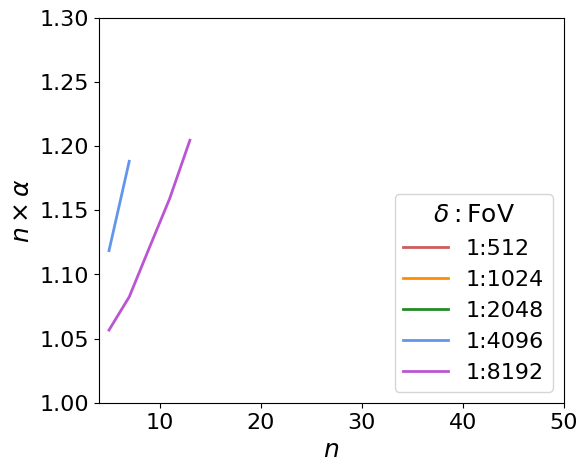

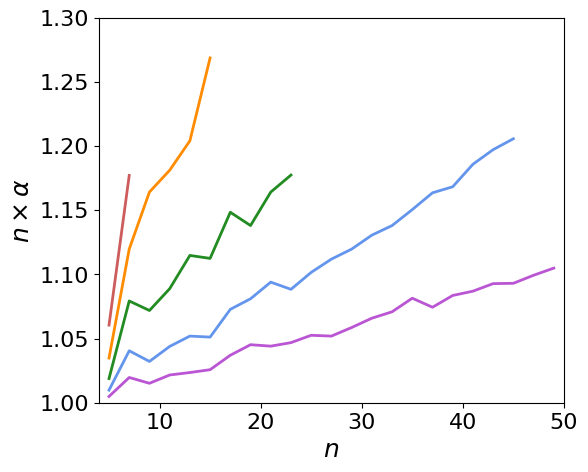

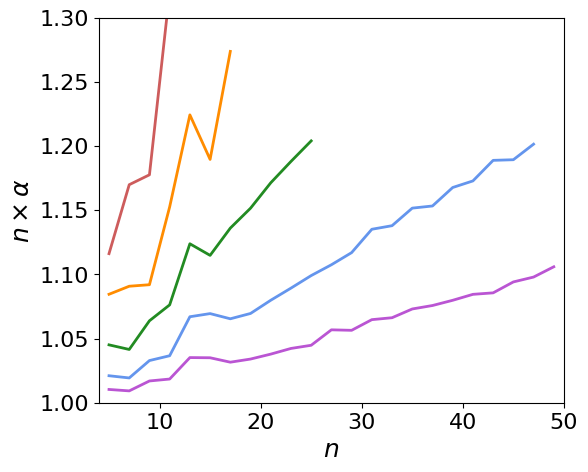

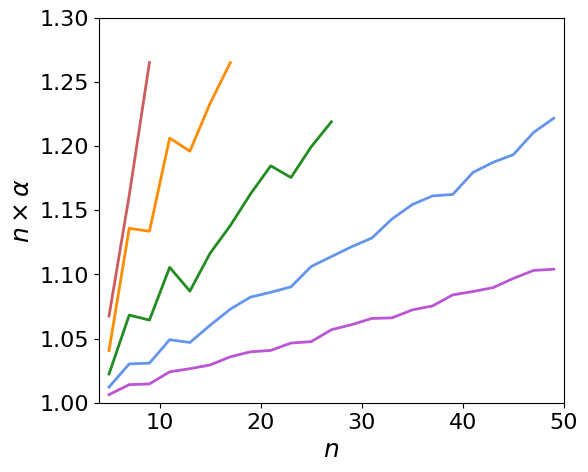

In [38]:
#matplotlib.rcParams['figure.figsize'] = [15, 3]

#fig, axs = plt.subplots(1, len(bda_levels))
npix=512
for i, bda_level in enumerate(totals):
    for j, resolution in enumerate(bda_level):
        plt.plot(Ns, resolution, label=str(delta) + ":" + str(resolutions[j] * npix), c=res_colours[j], lw=2)
    
    plt.xlabel("$n$", fontsize=18)
    plt.ylabel(r"$n \times \alpha$", fontsize=18)
    plt.xlim(4, 50)
    plt.ylim(1, 1.3)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    #plt.set_title(r"$\rho=" + str(bda_levels[i]/100) + "$")

    if i == 0:
        plt.legend(title=r"$\delta : \text{FoV}$", loc="lower right", fontsize=16, title_fontsize=18)

    #plt.tight_layout()
    plt.savefig("../figures/midbdavisdupe" + str(i) + ".pdf", pad_inches=0.0, bbox_inches='tight')
    plt.show()
#plt.show()

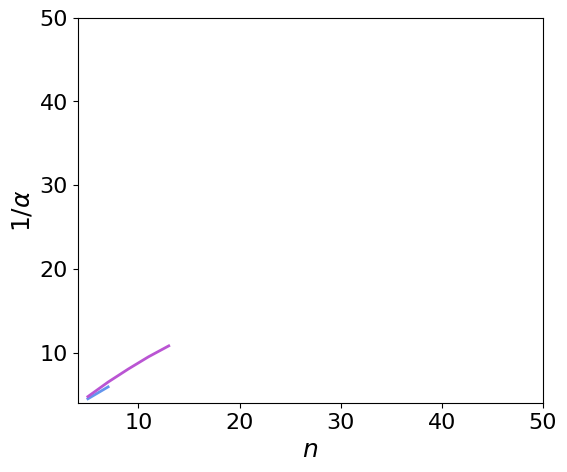

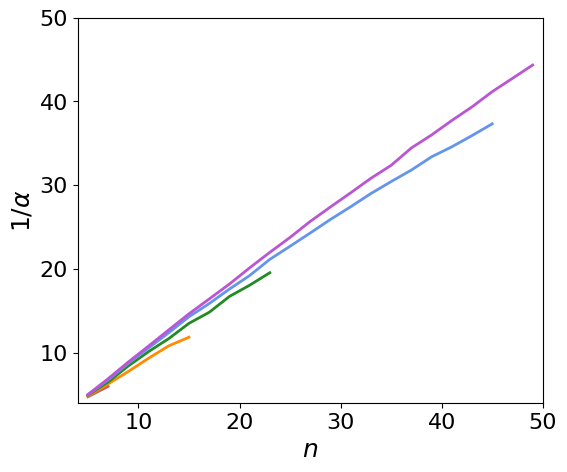

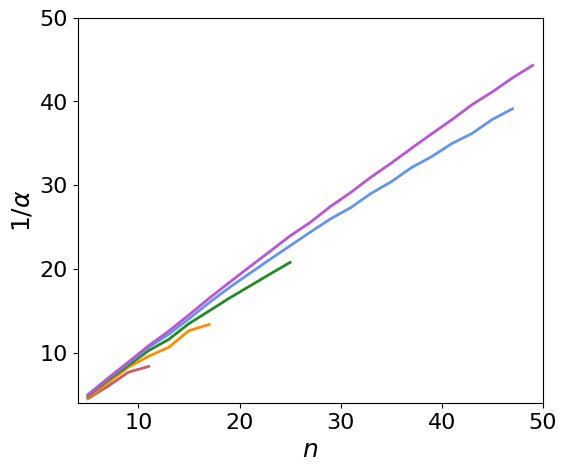

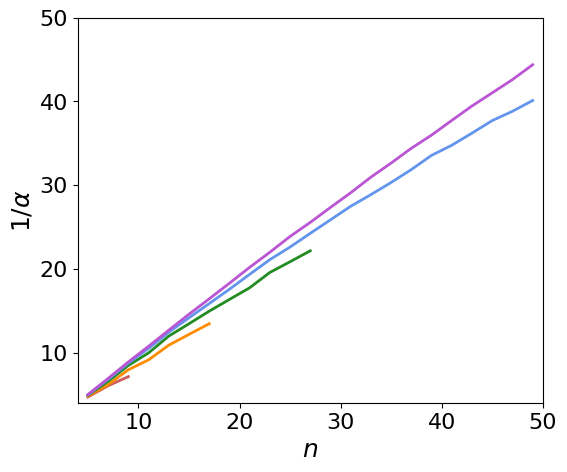

In [32]:
#fig, axs = plt.subplots(1, len(bda_levels))

for i, bda_level in enumerate(speedup):
    for j, resolution in enumerate(bda_level):
        plt.plot(Ns, resolution, label=str(delta) + ":" + str(resolutions[j] * npix), c=res_colours[j], lw=2)
    #plt.set_title(r"$\rho=" + str(bda_levels[i]/100) + "$")
    plt.xlabel("$n$", fontsize=18)
    plt.ylabel(r"$1 / \alpha$", fontsize=18)
    plt.xlim(4, 50)
    plt.ylim(4, 50)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    #if i == 0:
    #    axs[i].legend(loc="lower right")

    #fig.tight_layout()
    plt.savefig("../figures/midbdascaling" + str(i) + ".pdf", pad_inches=0.0, bbox_inches='tight')
    plt.show()

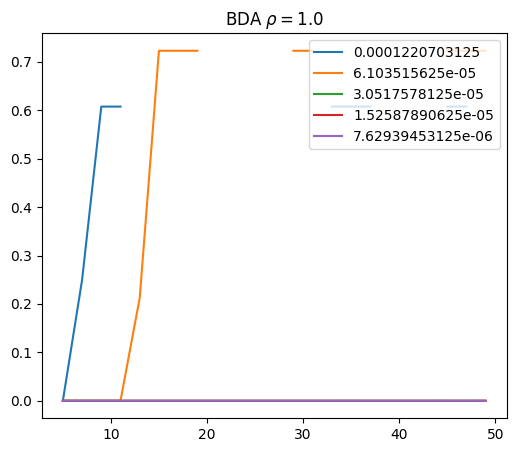

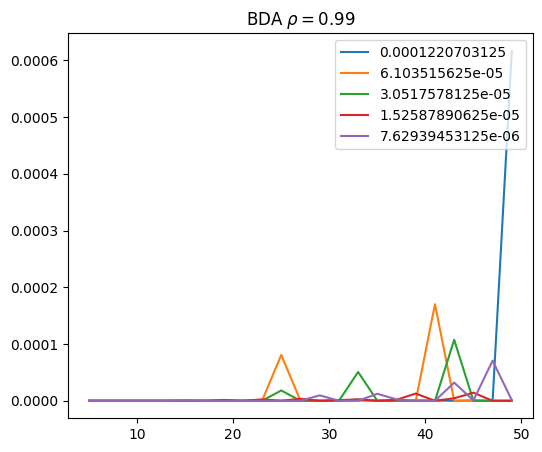

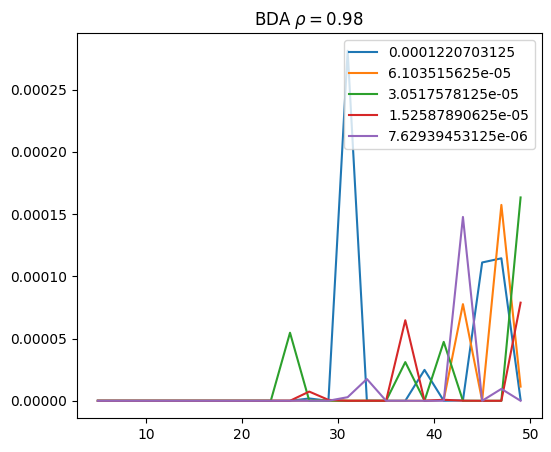

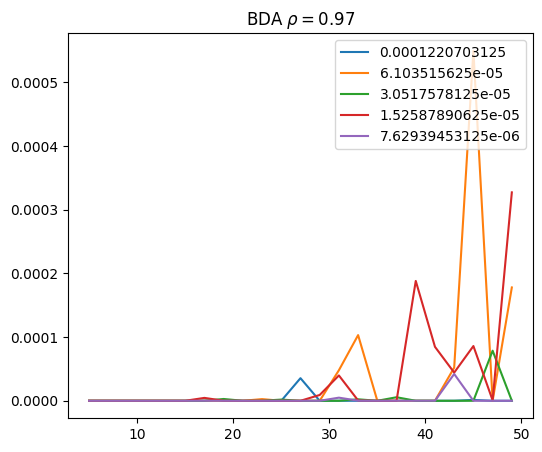


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 460/460 [00:33<00:00, 56.70it/s]

In [33]:
for i, bda_level in enumerate(stab):
    for j, resolution in enumerate(bda_level):
        plt.plot(Ns, resolution, label=str(delta/(resolutions[j] * npix)))
    plt.title(r"BDA $\rho=" + str(bda_levels[i]/100) + "$")
    plt.legend(loc="upper right")
    plt.show()

## Cost function visualization

In [18]:
num_partitions = 20
npixels = [512, 1024, 2048, 4096, 8192]
resolutions = [1, 2, 4, 8, 16]
delta = 1
num_samples = 1000
scale_factor = 1.8

alpha_range = numpy.arange(1.0/num_partitions, 2.0/num_partitions, 1.0/(num_partitions*num_samples))

msmid = "../data8/midbda99.ms/"

In [19]:
[vis], _ = ingest.create_visibility_from_ms(msmid, use_weight_spec=True, start_chan=0, end_chan=0, selected_dds=[0])

advice = advise_wide_field(vis, guard_band_image=3.0, delA=0.1, facets=1, oversampling_synthesised_beam=4.0)
cell_size = advice['cellsize'] * scale_factor

uvlambdas = numpy.array(vis.visibility_acc.uvw_lambda[..., 0, 0:2])
uvlambdas = uvlambdas.reshape((int(uvlambdas.shape[0] * uvlambdas.shape[1]), 2))
middist = numpy.zeros(uvlambdas.shape[0])
for i, uvlambda in enumerate(uvlambdas):
    middist[i] = numpy.sqrt(uvlambda[0]**2 + uvlambda[1]**2)  * cell_size * npixels[0]

mod_load: 9.5367431640625e-06
select source: 0.016638517379760742
select_dd: 1.6689300537109375e-06
tq: 0.014174461364746094
dddesc 0: 0.0008404254913330078
tquery 0: 0.01859307289123535
rtime 0: 0.0013659000396728516
rdatacol 0: 0.0007584095001220703
rdd initial 0: 0.020718097686767578
rchannum: 0.039795637130737305
averagechan: 3.814697265625e-06
ruvw: 0.0646054744720459
rpol: 0.0007193088531494141
rconfig: 0.0008983612060546875
makebaselines: 0.14144420623779297
readphasecenters: 0.17643189430236816
convert: 1.3537650108337402
createvis: 0.011586189270019531


In [20]:
samples = []

for resolution in resolutions:
    dist_rescaled = middist * resolution
    ecdf = ECDF(dist_rescaled)
    cdf = interp1d(ecdf.x, ecdf.y, bounds_error=False, assume_sorted=True)
    icdf = interp1d(ecdf.y, ecdf.x, bounds_error=False, assume_sorted=True)

    samples.append(partition.cost(cdf, icdf, delta, num_partitions, alpha_range))

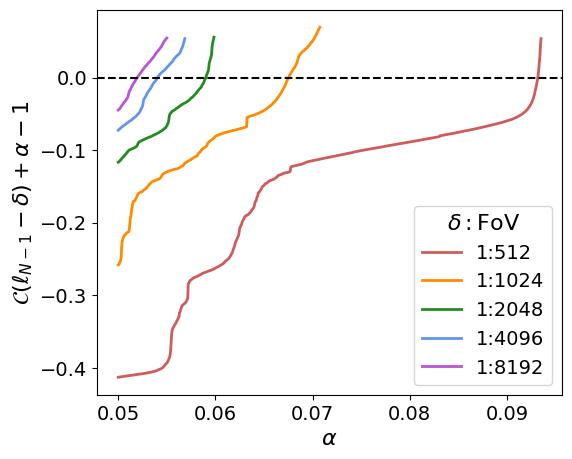

In [39]:
matplotlib.rcParams['figure.figsize'] = [6, 5]

fig, ax = plt.subplots(1, 1)

for i, npix in enumerate(npixels):
    ax.plot(alpha_range, samples[i], label=str(delta) + ":" + str(npix), c=res_colours[i], lw=2)
ax.axhline(y=0, c='black', ls='--')
#ax.set_title(r"$n=20$ SKA-Mid $\rho=0.99$")
ax.set_xlabel(r"$\alpha$", fontsize=16)
ax.set_ylabel(r"$\mathcal{C}(\ell_{N-1} - \delta) + \alpha - 1$", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.legend(loc="lower right", fontsize=14, title=r"$\delta : \text{FoV}$", title_fontsize=16)
plt.show()
#plt.xlim(alpha_range[0] - 0.001, alpha_range[-1] + 0.001)


fig.savefig("../figures/scalingcost.pdf", pad_inches=0.0, bbox_inches='tight')

[228.37431642 221.71330613  43.89989847 ... 108.89242939 229.05635488
 219.8831202 ]


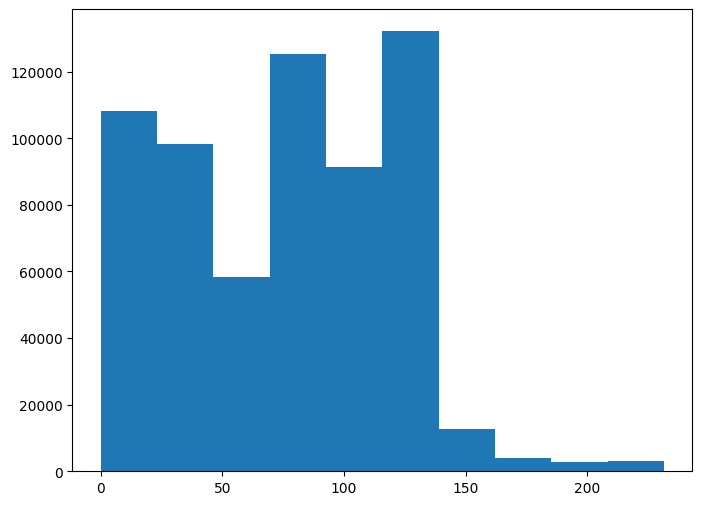

In [28]:
print(middist)
plt.hist(middist)
plt.show()